In [16]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


In [17]:
class Batsman(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    sr: float
    bpb: float
    boundary_percentage: float
    summary: str

In [18]:
def calculate_sr(state: Batsman) -> Batsman:
    sr = (state['runs'] / state['balls']) * 100
    return {'sr': sr}

In [19]:
def calculate_bpb(state:Batsman)->Batsman:
    bpb=state['balls']/(state['fours']+state['sixes'])
    

    return {"bpb":bpb} 


In [20]:
def calculate_boundaries_per(state: Batsman) -> Batsman:
    boundary_percentage = (((state['fours'] * 4) + (state['sixes'] * 6)) / state['runs']) * 100
    return {'boundary_percentage': boundary_percentage}

In [21]:
def summary(state: Batsman) -> Batsman:
    summary_text = f"""Strike rate - {state['sr']}
Balls per boundary - {state['bpb']}
Boundary percentage - {state['boundary_percentage']}"""
    return {'summary': summary_text}

In [22]:
graph=StateGraph(Batsman)

graph.add_node('Calculate_sr',calculate_sr)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('calculate_boundaries_per',calculate_boundaries_per)
graph.add_node('summary',summary)

graph.add_edge(START,'Calculate_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_boundaries_per')

graph.add_edge('Calculate_sr','summary')
graph.add_edge('calculate_bpb','summary')
graph.add_edge('calculate_boundaries_per','summary')

graph.add_edge('summary',END)

workflow=graph.compile()








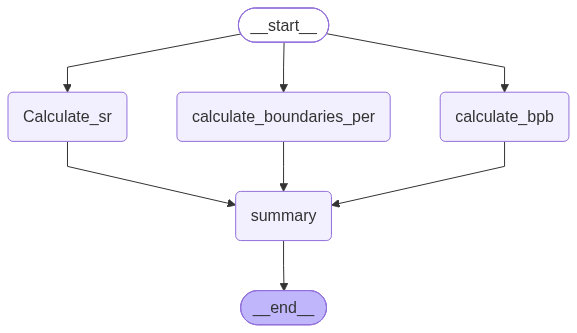

In [23]:
workflow

In [24]:
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4,
}

final_state = workflow.invoke(initial_state)
print(final_state['summary'])

Strike rate - 200.0
Balls per boundary - 5.0
Boundary percentage - 48.0
